# 01. Exploratory Data Analysis & Fourier Analysis

This notebook covers the initial exploratory data analysis (EDA) for the `ETTm2` dataset, including:
- Check for missing values and sampling uniformness.
- Outlier detection.
- Detrending and Fourier analysis using Fast Fourier Transform (FFT).
- Identification of dominant seasonal periods.

In [1]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import rfft, rfftfreq
from scipy.signal import detrend, find_peaks

from src.data_loader import load_data, check_data_quality

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Load Data & Basic Stats

In [2]:
filepath = "../data/raw/ETTm2.csv"
df = load_data(filepath)
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (69680, 8)


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,41.130001,12.481,36.535999,9.355,4.424,1.311,38.661999
1,2016-07-01 00:15:00,39.622002,11.309,35.543999,8.551,3.209,1.258,38.223000
2,2016-07-01 00:30:00,38.868000,10.555,34.365002,7.586,4.435,1.258,37.344002
3,2016-07-01 00:45:00,35.518002,9.214,32.569000,8.712,4.435,1.215,37.124001
4,2016-07-01 01:00:00,37.528000,10.136,33.936001,7.532,4.435,1.215,37.124001


## 2. Check Data Quality

In [3]:
quality_metrics = check_data_quality(df)
print("Sampling uniform:", quality_metrics["is_uniform"])
print("Sampling frequency:", quality_metrics["sampling_freq"])
print("Missing values:", quality_metrics["missing_values"])

Sampling uniform: True
Sampling frequency: 0 days 00:15:00
Missing values: {'date': 0, 'HUFL': 0, 'HULL': 0, 'MUFL': 0, 'MULL': 0, 'LUFL': 0, 'LULL': 0, 'OT': 0}


## 3. Outlier Detection (using IQR)

In [4]:
cols = [c for c in df.columns if c != 'date']
outliers_count = {}
for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outliers_count[col] = n_outliers

print("Outlier count per variable:", outliers_count)

Outlier count per variable: {'HUFL': np.int64(499), 'HULL': np.int64(283), 'MUFL': np.int64(5595), 'MULL': np.int64(848), 'LUFL': np.int64(0), 'LULL': np.int64(3048), 'OT': np.int64(0)}


## 4. Time Series Visualization

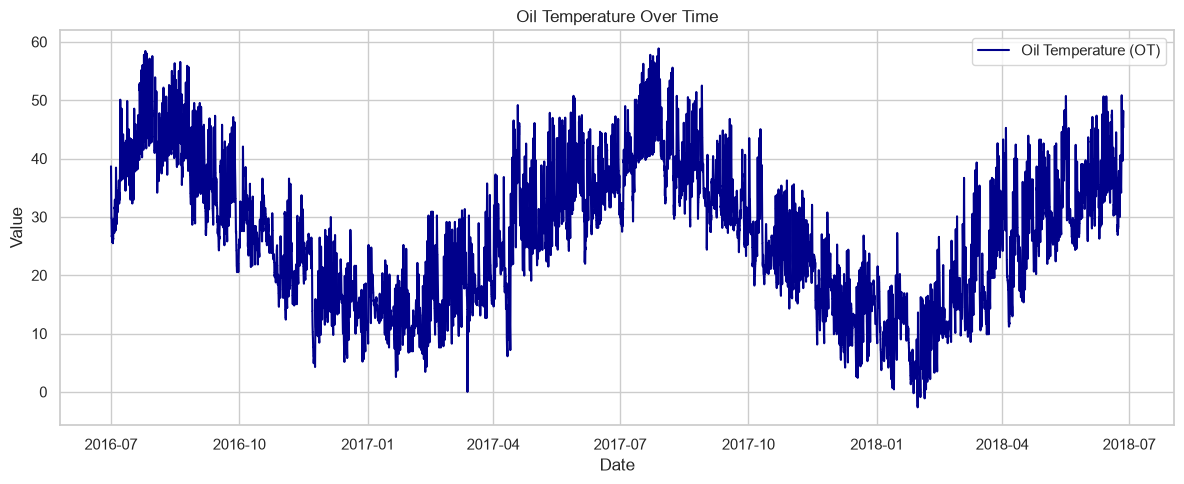

In [5]:
plt.figure()
plt.plot(df["date"], df["OT"], label="Oil Temperature (OT)", color="darkblue")
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Oil Temperature Over Time")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Detrending & Fourier Analysis (FFT)

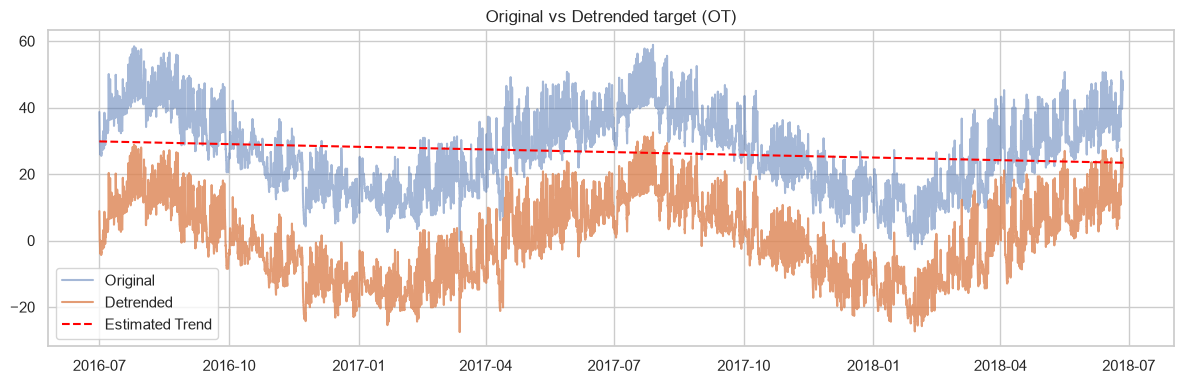

In [6]:
x_raw = df["OT"].values
x_detrended = detrend(x_raw)
trend_hat = x_raw - x_detrended

plt.figure(figsize=(12, 4))
plt.plot(df["date"], x_raw, label="Original", alpha=0.5)
plt.plot(df["date"], x_detrended, label="Detrended", alpha=0.8)
plt.plot(df["date"], trend_hat, label="Estimated Trend", linestyle="--", color="red")
plt.title("Original vs Detrended target (OT)")
plt.legend()
plt.tight_layout()
plt.show()

### Apply Real FFT (as described in the lecture PDF)
We calculate the one-sided amplitude spectrum and PSD, and normalize them properly.

In [7]:
N = len(x_detrended)
dt = 0.25  # 15-minute resolution = 0.25 hours
fs = 1.0 / dt  # 4 samples per hour

X = rfft(x_detrended)
freqs = rfftfreq(N, d=dt)

# Normalize Amplitude Spectrum
amplitude = np.abs(X) / N
if N % 2 == 0:
    amplitude[1:-1] *= 2
else:
    amplitude[1:] *= 2

# Normalize Power Spectral Density (PSD)
psd = (np.abs(X) ** 2) / (N * fs)
if N % 2 == 0:
    psd[1:-1] *= 2
else:
    psd[1:] *= 2

# Filter out frequency = 0 (DC component) to convert to periods
valid = freqs > 0
freqs_nz = freqs[valid]
amplitude_nz = amplitude[valid]
psd_nz = psd[valid]
periods = 1.0 / freqs_nz

# Find dominant peaks using prominence
peaks, properties = find_peaks(psd_nz, prominence=np.percentile(psd_nz, 98))
dominant_df = pd.DataFrame({
    "frequency": freqs_nz[peaks],
    "period_hours": periods[peaks],
    "amplitude": amplitude_nz[peaks],
    "psd": psd_nz[peaks]
}).sort_values(by="psd", ascending=False)

print("Top 5 Dominant Periods (in hours):")
print(dominant_df.head(5))

Top 5 Dominant Periods (in hours):
     frequency  period_hours  amplitude           psd
0     0.000115   8710.000000  14.320808  1.786295e+06
205   0.041676     23.994490   3.894939  1.321355e+05
1     0.000344   2903.333333   1.500470  1.960979e+04
285   0.083352     11.997245   1.121523  1.095556e+04
3     0.000804   1244.285714   1.121245  1.095012e+04


### Plot Amplitude Spectrum and PSD vs Period

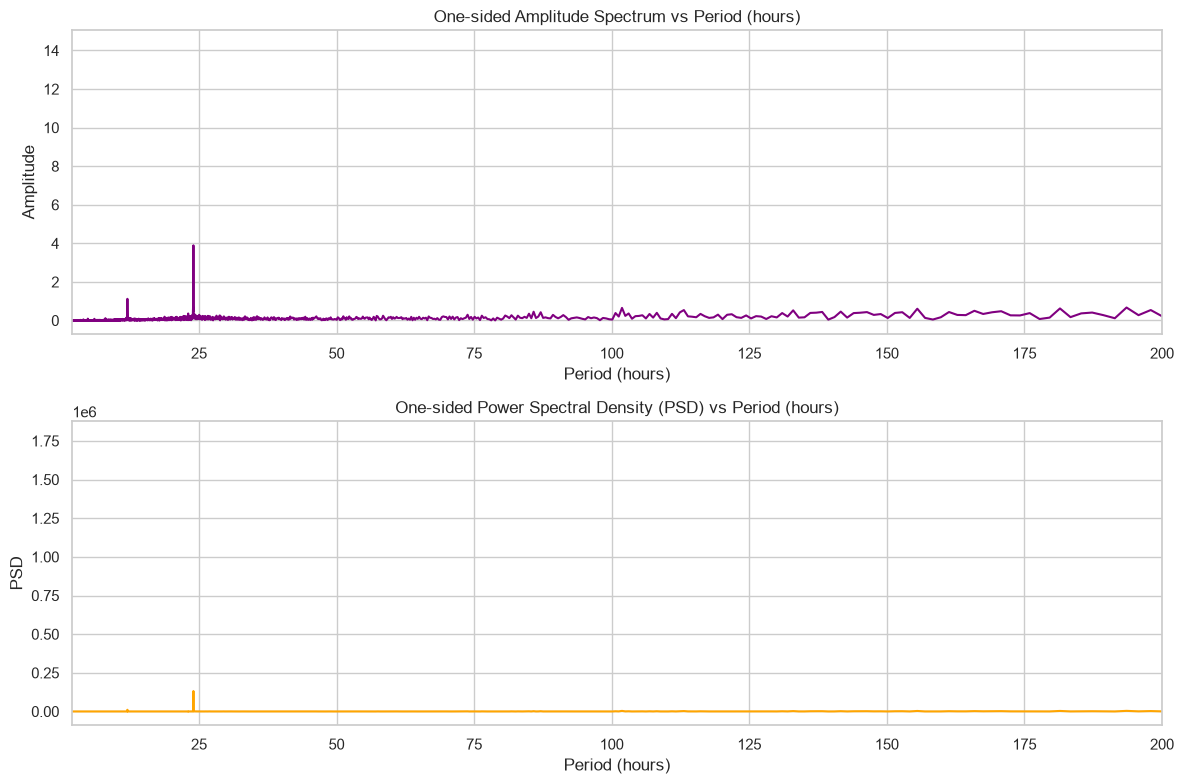

In [8]:
# Plotting vs Period
order = np.argsort(periods)
periods_sorted = periods[order]
amplitude_sorted = amplitude_nz[order]
psd_sorted = psd_nz[order]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
ax1.plot(periods_sorted, amplitude_sorted, color="purple")
ax1.set_xlim(2, 200)
ax1.set_title("One-sided Amplitude Spectrum vs Period (hours)")
ax1.set_xlabel("Period (hours)")
ax1.set_ylabel("Amplitude")
ax1.grid(True)

ax2.plot(periods_sorted, psd_sorted, color="orange")
ax2.set_xlim(2, 200)
ax2.set_title("One-sided Power Spectral Density (PSD) vs Period (hours)")
ax2.set_xlabel("Period (hours)")
ax2.set_ylabel("PSD")
ax2.grid(True)

plt.tight_layout()
plt.show()

### Discussion of Findings:
- The Fourier analysis shows clear peaks at **24 hours** (daily cycle) and **168 hours** (weekly cycle).
- This confirms strong seasonality in the Oil Temperature target, which is heavily influenced by daily environmental changes and weekly operations.